In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()
df=pd.read_csv('training_data.csv')

Saving training_data.csv to training_data.csv


In [6]:

print(f"shape:{df.shape}")
df.head()

shape:(4750, 10)


,click_count,avg_click_interval,click_interval_variance,click_interval_entropy,mouse_velocity_variance,max_element_click_rate,scroll_events,keystroke_count,persona,label
0,200,22.609732,6.132684,0.014982,0.000000,39.292982,0.0,0.0,http_flooder,bot
1,8,1524.943564,269875.235918,2.304230,0.356148,1.201258,11.0,5.0,casual_browser,human
2,4,1540.784354,254741.917130,2.607192,0.786881,1.449804,11.0,3.0,casual_browser,human
3,15,477.774439,114469.093339,2.897984,0.321347,1.323701,2.0,56.0,power_user,human
4,19,428.310760,117565.233111,2.981485,1.028971,2.472009,3.0,58.0,power_user,human


In [8]:
df.info
print("null values:",df.isnull().sum)

null values: <bound method DataFrame.sum of       click_count  avg_click_interval  click_interval_variance  \
0           False               False                    False   
1           False               False                    False   
2           False               False                    False   
3           False               False                    False   
4           False               False                    False   
...           ...                 ...                      ...   
4745        False               False                    False   
4746        False               False                    False   
4747        False               False                    False   
4748        False               False                    False   
4749        False               False                    False   

      click_interval_entropy  mouse_velocity_variance  max_element_click_rate  \
0                      False                    False                   False   
1

In [7]:
df.describe()

,click_count,avg_click_interval,click_interval_variance,click_interval_entropy,mouse_velocity_variance,max_element_click_rate,scroll_events,keystroke_count
count,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000
mean,19.602737,830.673581,126796.964678,2.147238,0.383493,3.592429,4.522105,19.211871
std,44.557815,433.903829,88413.766630,1.096883,0.387559,9.143032,4.074717,17.898303
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.101404,0.000000,0.000000
25%,5.000000,488.450264,62722.022356,1.816425,0.021064,0.771587,1.000000,6.250000
50%,8.000000,857.830092,133450.487458,2.498620,0.308566,1.264922,4.000000,11.000000
75%,15.000000,1120.374936,186224.835007,2.910560,0.697012,2.377436,7.000000,38.063147
max,299.000000,2258.716556,436416.804336,4.263109,1.687052,59.975886,22.000000,65.000000


In [10]:
features=[
    'click_count',
    'avg_click_interval',
    'click_interval_variance',
    'click_interval_entropy',
    'mouse_velocity_variance',
    'max_element_click_rate',
    'scroll_events',
    'keystroke_count'
]
df.groupby('label')[features].mean().T

label,bot,human
click_count,55.552000,10.016267
avg_click_interval,589.891802,894.882055
click_interval_variance,153.827623,160568.467893
click_interval_entropy,0.219515,2.661297
mouse_velocity_variance,0.005824,0.484205
max_element_click_rate,11.581819,1.461925
scroll_events,0.241000,5.663733
keystroke_count,9.545387,21.789600


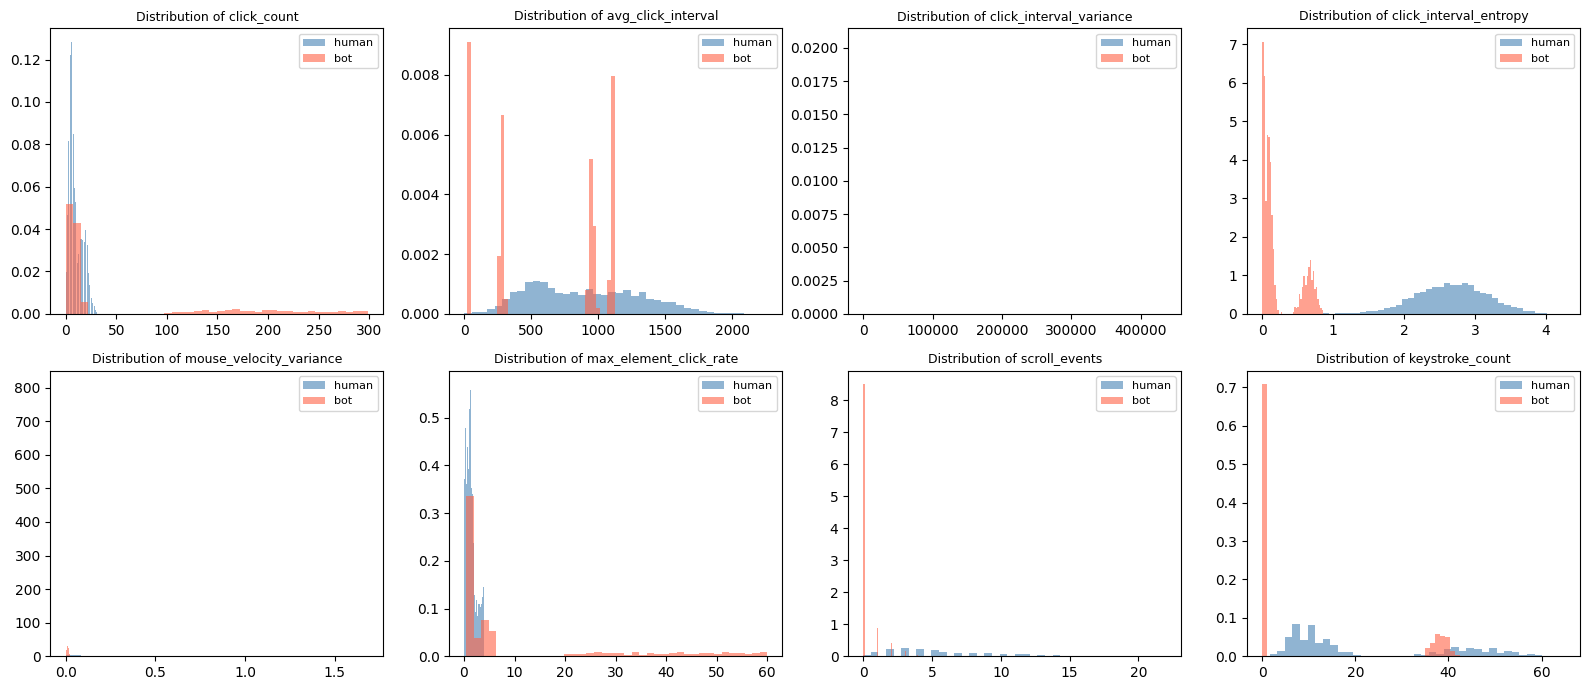

In [13]:
fig,axes=plt.subplots(2,4,figsize=(16,7))
axes=axes.flatten()

for i, feat in enumerate(features):
  for label,color in[('human','steelblue'),('bot','tomato')]:
    axes[i].hist(df[df['label']==label][feat],
                 bins=40,alpha=0.6,color=color,label=label,density=True)
    axes[i].set_title(f'Distribution of {feat}',fontsize=9)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

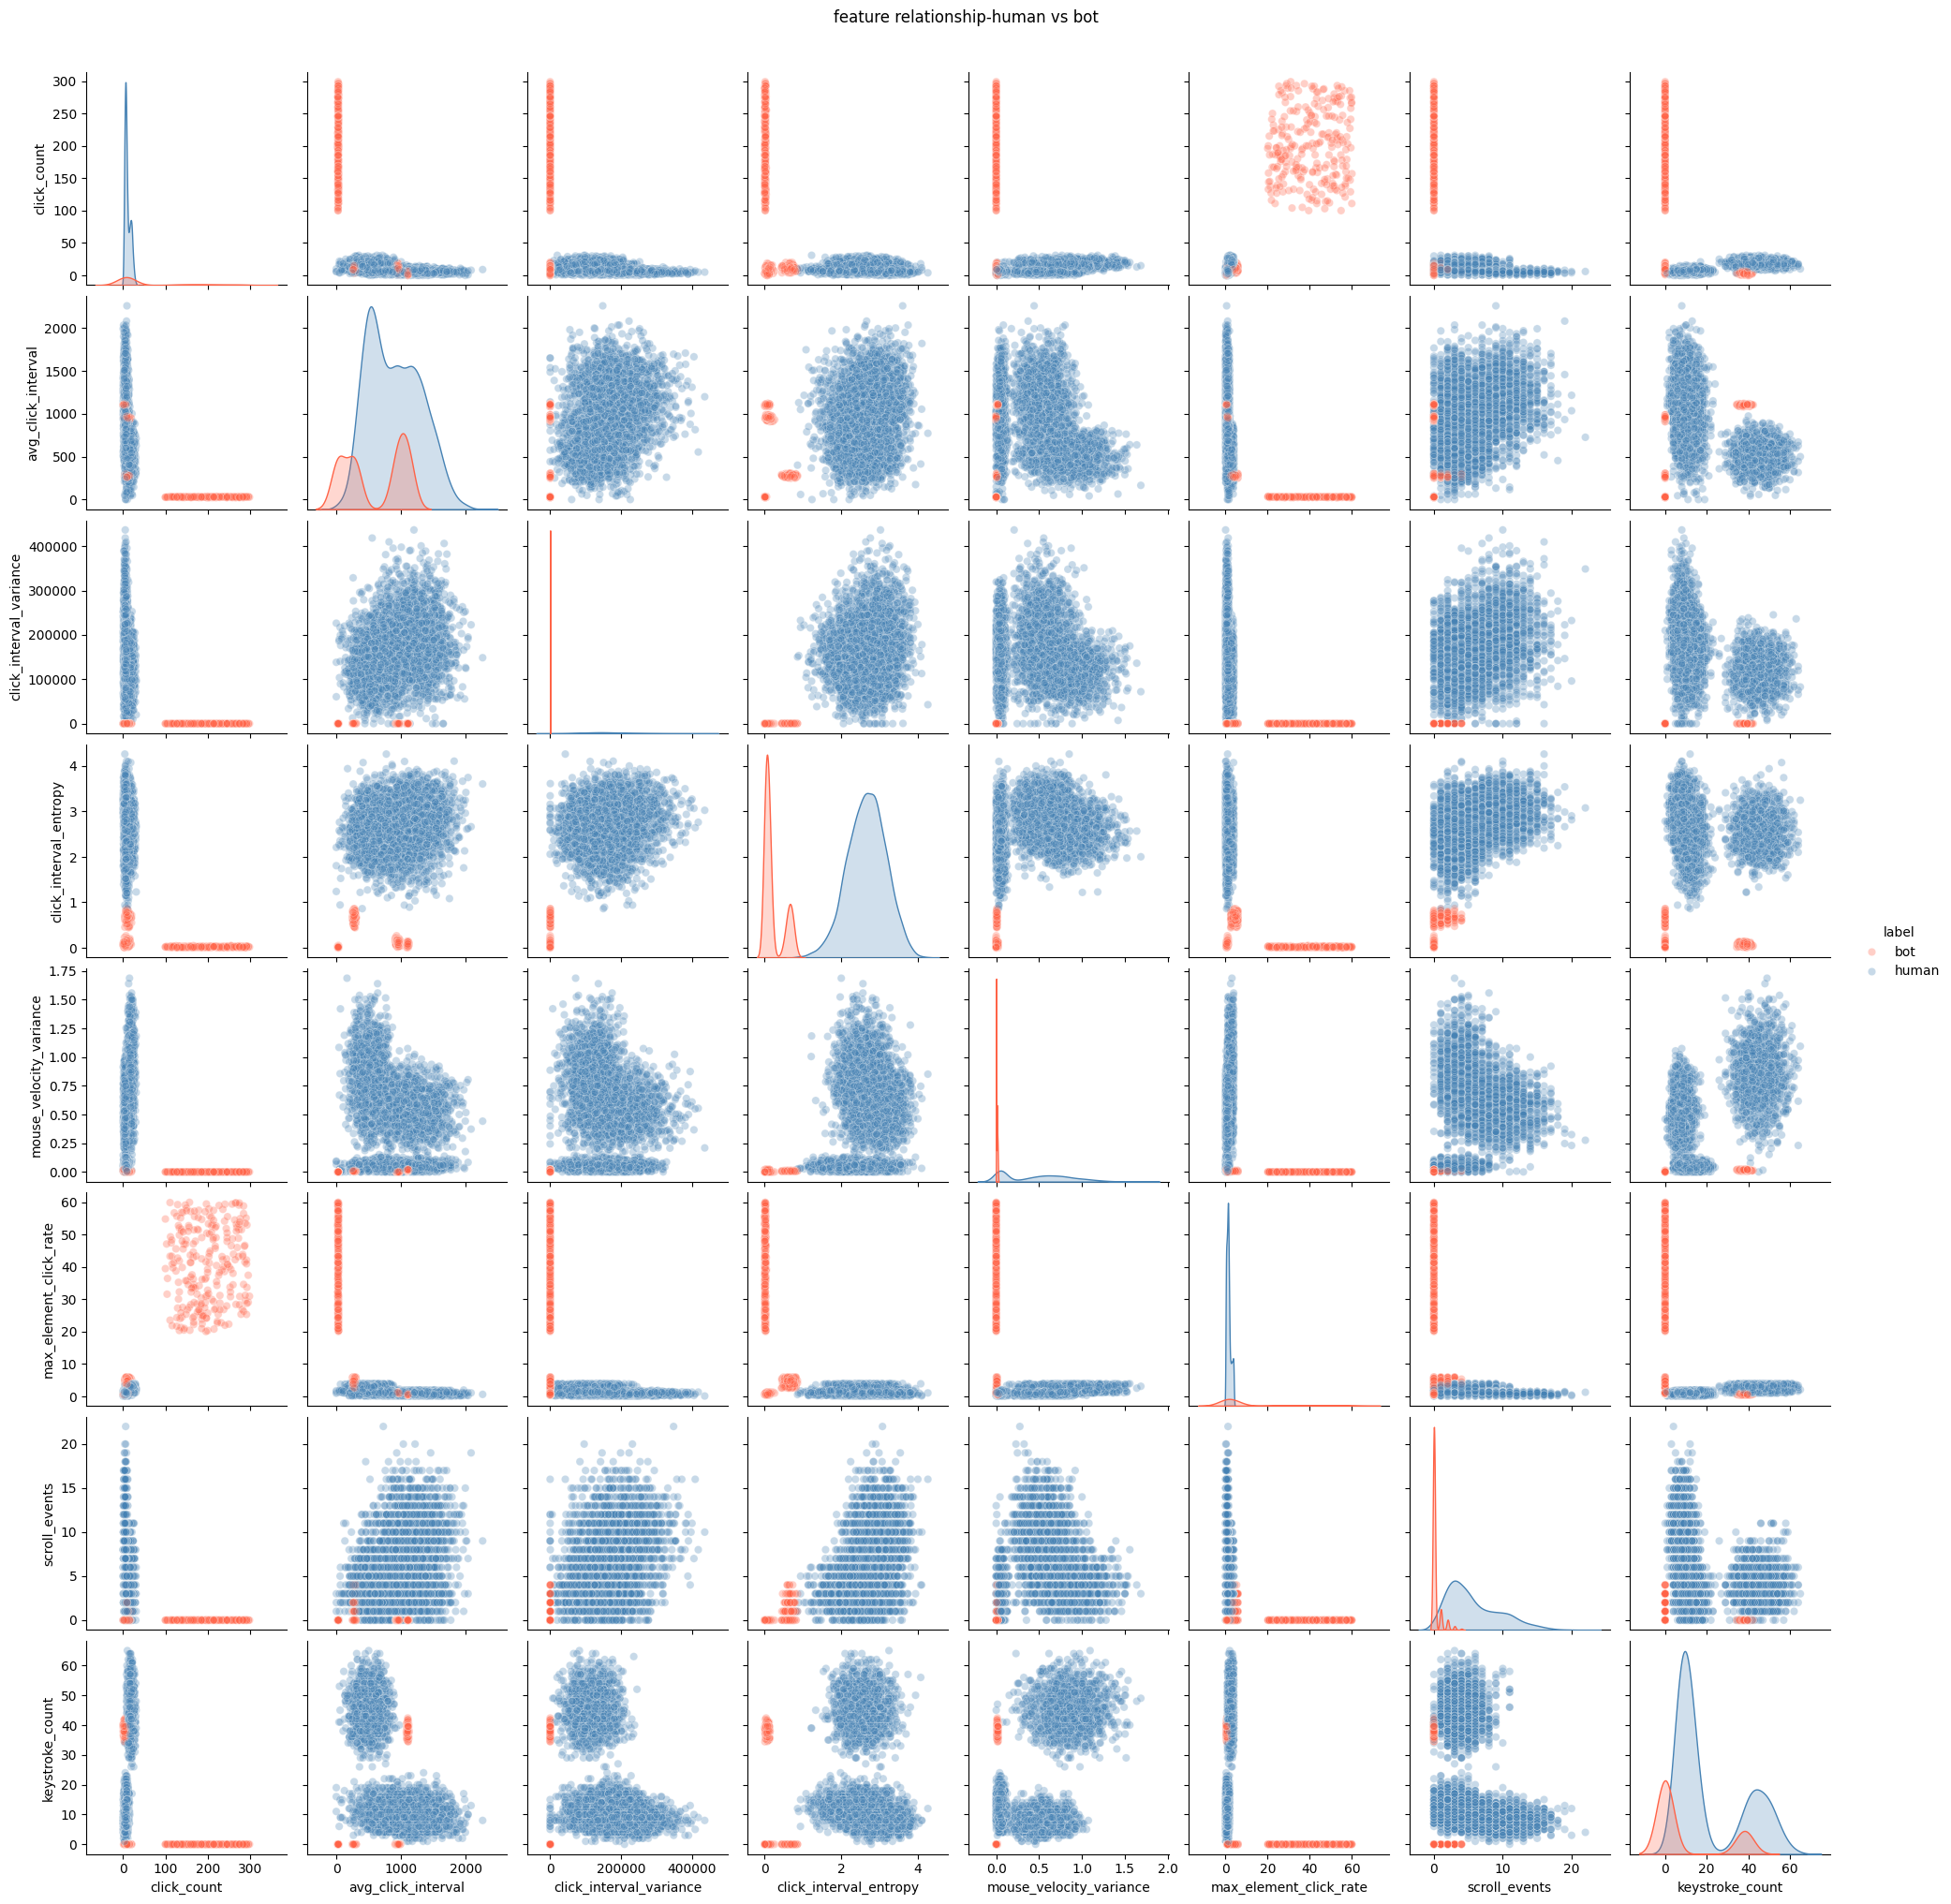

In [17]:
import seaborn as sns
sns.pairplot(df[features+['label']],hue='label',
             palette={'human':'steelblue','bot':'tomato'},
             plot_kws={'alpha':0.3},diag_kind="kde")
plt.suptitle('feature relationship-human vs bot',y=1.02)
plt.show()

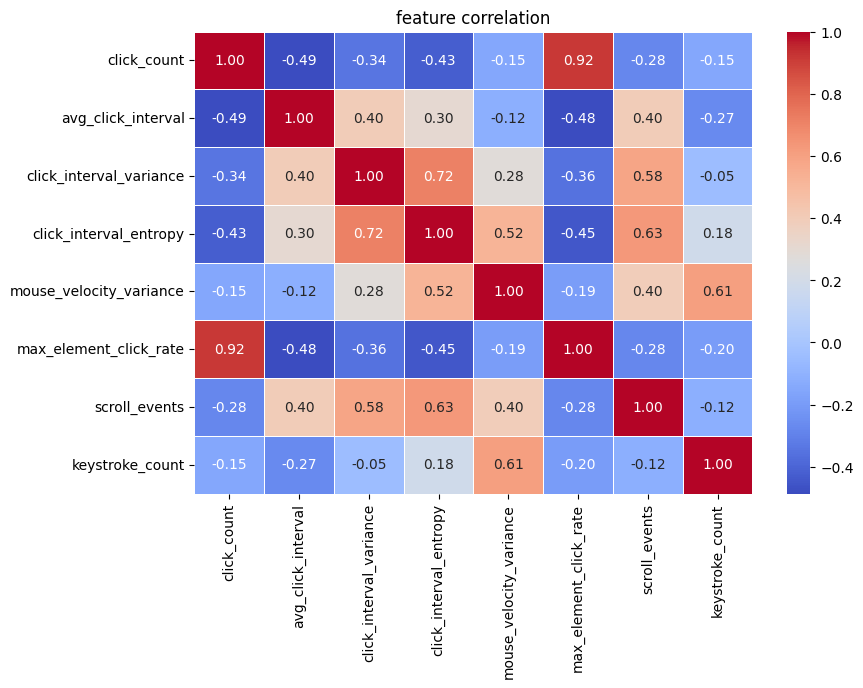

In [18]:
plt.figure(figsize=(9,6))
sns.heatmap(df[features].corr(),annot=True,fmt='.2f',
            cmap='coolwarm',linewidth=0.5
            )
plt.title('feature correlation')
plt.show()

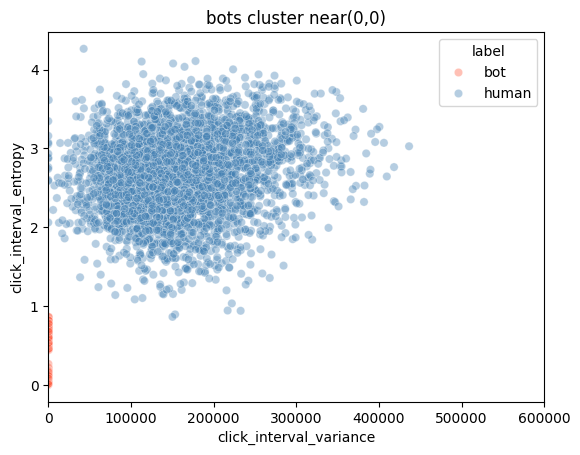

In [21]:
sns.scatterplot(data=df,x='click_interval_variance',y='click_interval_entropy',
               hue='label',alpha=0.4,
               palette={'human':'steelblue','bot':'tomato'})
plt.title('bots cluster near(0,0)')
plt.xlim(0,600000)
plt.show()

/tmp/ipykernel_18720/3861737417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='label',y=feat,
/tmp/ipykernel_18720/3861737417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='label',y=feat,
/tmp/ipykernel_18720/3861737417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='label',y=feat,
/tmp/ipykernel_18720/3861737417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effec

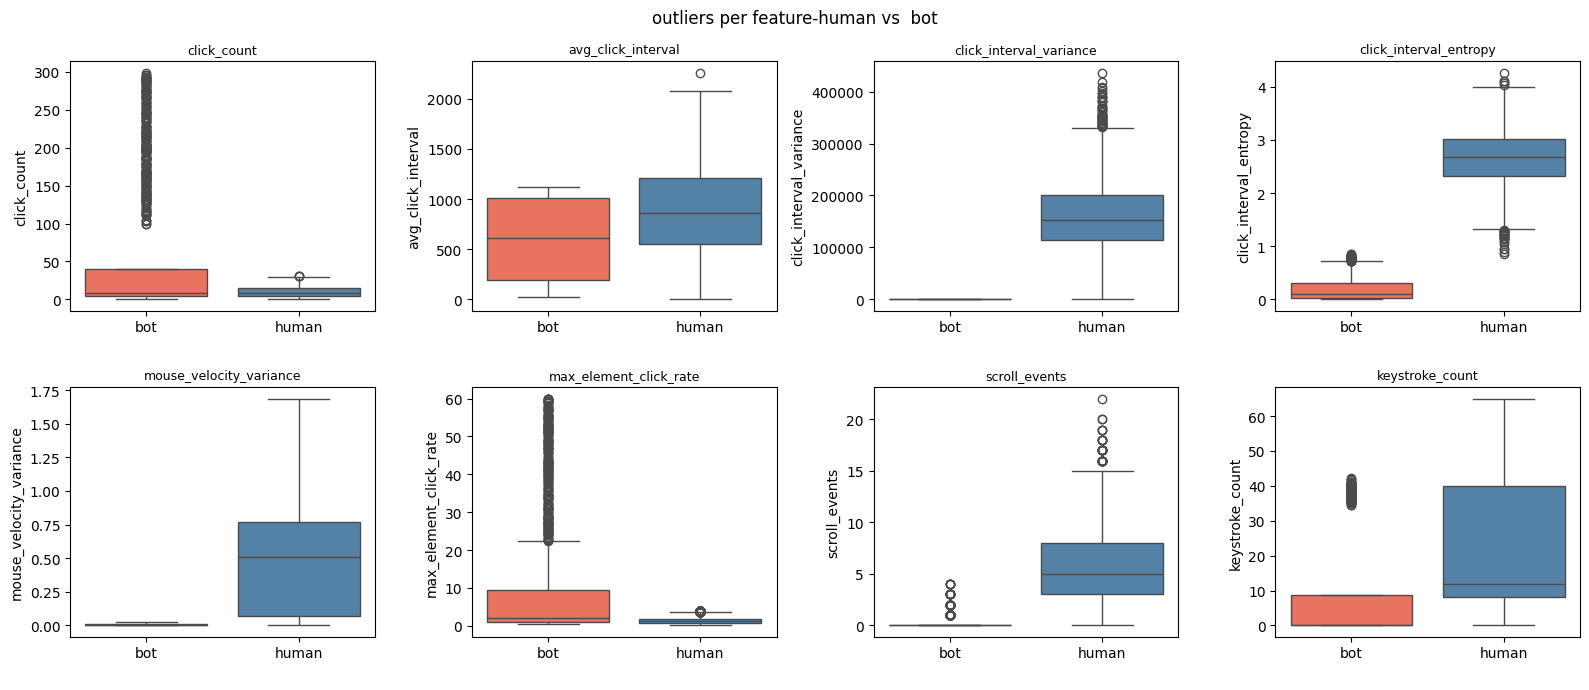

In [25]:
fig,axes=plt.subplots(2,4,figsize=(16,7))
axes=axes.flatten()

for i,feat in enumerate(features):
  sns.boxplot(data=df,x='label',y=feat,
              palette={'human':'steelblue','bot':'tomato'},ax=axes[i])
  axes[i].set_title(feat,fontsize=9)
  axes[i].set_xlabel(' ')
plt.suptitle('outliers per feature-human vs  bot', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
df.groupby('label')[features].mean().T.style.background_gradient(cmap='RdYlGn',axis=1)

label,bot,human
click_count,55.552000,10.016267
avg_click_interval,589.891802,894.882055
click_interval_variance,153.827623,160568.467893
click_interval_entropy,0.219515,2.661297
mouse_velocity_variance,0.005824,0.484205
max_element_click_rate,11.581819,1.461925
scroll_events,0.241000,5.663733
keystroke_count,9.545387,21.789600
